## Установка библиотек и вывод датасета

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import Callback
df = pd.read_csv("filtered_thyroid_data.csv")
df.head(5)

,Age,Gender,Hx Radiothreapy,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


## Замена категориальных данных на количественные

In [4]:
class RussianLogger(Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"Эпоха {epoch+1}: точность = {logs['accuracy']:.4f}, точность на валидации = {logs['val_accuracy']:.4f}")
categorical_cols = ['Gender', 'Hx Radiothreapy', 'Adenopathy', 'Pathology',
                    'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
df['Recurred'] = df['Recurred'].map({'No': 0, 'Yes': 1})
df.head(5)

,Age,Gender,Hx Radiothreapy,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,0,0,3,2,1,2,0,0,0,0,2,0
1,34,0,0,3,2,1,2,0,0,0,0,1,0
2,30,0,0,3,2,1,2,0,0,0,0,1,0
3,62,0,0,3,2,1,2,0,0,0,0,1,0
4,62,0,0,3,2,0,2,0,0,0,0,1,0


## Распределение датасета на обучащий и тестовый наборы

In [5]:
X = df.drop('Recurred', axis=1)
y = df['Recurred']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("\nОбучающий набор данных (x_train):")
print(x_train.head(5))
print("\nЦелевая переменная обучающего набора (y_train):")
print(y_train.head(5))
print("\nТестовый набор данных (x_test):")
print(x_test.head(5))
print("\nЦелевая переменная тестового набора (y_test):")
print(y_test.head(5))


Обучающий набор данных (x_train):
     Age  Gender  Hx Radiothreapy  Adenopathy  Pathology  Focality  Risk  T  \
165   40       0                0           3          3         0     2  2   
321   62       0                0           5          3         0     1  3   
220   29       0                0           3          3         1     2  2   
94    37       0                0           3          1         0     2  2   
232   31       0                0           2          3         1     1  2   

     N  M  Stage  Response  
165  0  0      0         1  
321  2  0      1         3  
220  1  0      0         2  
94   0  0      0         1  
232  2  0      0         3  

Целевая переменная обучающего набора (y_train):
165    0
321    1
220    0
94     0
232    1
Name: Recurred, dtype: int64

Тестовый набор данных (x_test):
     Age  Gender  Hx Radiothreapy  Adenopathy  Pathology  Focality  Risk  T  \
268   32       0                0           3          3         1     2  3   
25

## Нормализация признаков

In [6]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_train_scaled_df = pd.DataFrame(x_train_scaled, columns=x_train.columns, index=x_train.index)
x_test_scaled_df = pd.DataFrame(x_test_scaled, columns=x_test.columns, index=x_test.index)
print(x_test_scaled[:5])
print(x_train_scaled[:5])

[[-0.60770939 -0.51933568 -0.14142136  0.05471183  0.4987207   0.77594732
   0.6979317   0.55453253 -0.66342407 -0.21063855 -0.32628    -0.63689373]
 [-0.7390828  -0.51933568 -0.14142136  1.72889391 -2.79498868  0.77594732
   0.6979317   0.55453253 -0.66342407 -0.21063855 -0.32628    -0.63689373]
 [-0.7390828  -0.51933568 -0.14142136 -2.45656128  0.4987207  -1.28874729
  -0.84965598  0.55453253  1.63044898 -0.21063855 -0.32628     1.51658121]
 [ 0.64033808 -0.51933568 -0.14142136  0.05471183 -2.79498868  0.77594732
  -0.84965598  0.55453253 -0.66342407 -0.21063855 -0.32628     1.51658121]
 [ 0.11484441 -0.51933568 -0.14142136  0.05471183  0.4987207   0.77594732
   0.6979317  -0.96732355 -0.66342407 -0.21063855 -0.32628    -0.63689373]]
[[-0.08221572 -0.51933568 -0.14142136  0.05471183  0.4987207  -1.28874729
   0.6979317  -0.20639551 -0.66342407 -0.21063855 -0.32628    -0.63689373]
 [ 1.36289187 -0.51933568 -0.14142136  1.72889391  0.4987207  -1.28874729
  -0.84965598  0.55453253  1.63

## Модель XGBoost

In [12]:
print("\n--- XGBoost ---")
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))


--- XGBoost ---
XGBoost Accuracy: 0.974025974025974
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        58
           1       0.95      0.95      0.95        19

    accuracy                           0.97        77
   macro avg       0.97      0.97      0.97        77
weighted avg       0.97      0.97      0.97        77



## Модель Linear SVM

In [13]:
print("\n--- Linear SVM ---")
linear_svc = LinearSVC(max_iter=10000, random_state=42)
linear_svc.fit(x_train, y_train)
y_pred_lsvc = linear_svc.predict(x_test)
print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_lsvc))
print(classification_report(y_test, y_pred_lsvc))


--- Linear SVM ---
Linear SVM Accuracy: 0.922077922077922
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        58
           1       0.88      0.79      0.83        19

    accuracy                           0.92        77
   macro avg       0.91      0.88      0.89        77
weighted avg       0.92      0.92      0.92        77



## Модель Random Forest

In [14]:
print("\n--- Random Forest ---")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


--- Random Forest ---
Random Forest Accuracy: 0.974025974025974
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        58
           1       1.00      0.89      0.94        19

    accuracy                           0.97        77
   macro avg       0.98      0.95      0.96        77
weighted avg       0.97      0.97      0.97        77



## Визуализация сравнения моделей

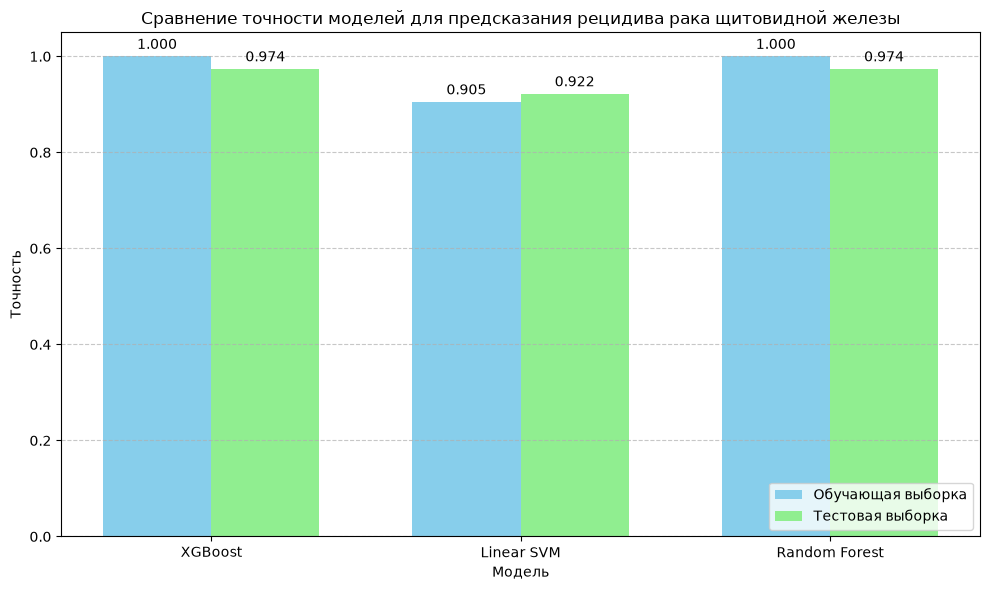

In [15]:
models = ['XGBoost', 'Linear SVM', 'Random Forest']
train_acc = [
    xgb.score(x_train, y_train),
    linear_svc.score(x_train, y_train),
    rf.score(x_train, y_train)
]
test_acc = [
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_lsvc),
    accuracy_score(y_test, y_pred_rf)
]

x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_acc, width, label='Обучающая выборка', color='skyblue')
rects2 = ax.bar(x + width/2, test_acc, width, label='Тестовая выборка', color='lightgreen')
ax.set_ylabel('Точность')
ax.set_xlabel('Модель')
ax.set_title('Сравнение точности моделей для предсказания рецидива рака щитовидной железы')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
def autolabel(rects):
    for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
plt.tight_layout()
plt.show()

